In [1]:
import os
import requests
from io import BytesIO
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import tensorflow_datasets as tfd

In [2]:
!pip install -y tensorflow


Usage:   
  pip install [options] <requirement specifier> [package-index-options] ...
  pip install [options] -r <requirements file> [package-index-options] ...
  pip install [options] [-e] <vcs project url> ...
  pip install [options] [-e] <local project path> ...
  pip install [options] <archive url/path> ...

no such option: -y


In [3]:
pip install tensorflow-macos==2.16.2 tensorflow-metal==1.2.0 tensorflow-datasets

Note: you may need to restart the kernel to use updated packages.


In [4]:
import os
import requests
from io import BytesIO
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import tensorflow_datasets as tfds


In [5]:
# Set random seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

In [6]:
import tensorflow_datasets as tfds

print(tfds.__file__)
print(hasattr(tfds, "load"))

/Users/yohanshah/Documents/what/.venv/lib/python3.12/site-packages/tensorflow_datasets/__init__.py
True


In [7]:
print(dir(tfds)[:20])

['GenerateMode', 'ImageFolder', 'ReadConfig', 'Split', 'TranslateFolder', '__all__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', 'annotations', 'as_dataframe', 'as_numpy', 'audio']


In [8]:
# 1. Load Data & Data Cleaning / Inspection
print("1. Loading 'cats_vs_dogs' from TensorFlow Datasets...")
# Load raw dataset splits (80% train, 20% validation)
(ds_train_raw, ds_val_raw), ds_info = tfds.load(
    "cats_vs_dogs",
    split=["train[:80%]", "train[80%:]"],
    as_supervised=True,

    with_info=True
)


1. Loading 'cats_vs_dogs' from TensorFlow Datasets...


2026-07-31 14:31:24.514141: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3
2026-07-31 14:31:24.514290: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-07-31 14:31:24.514299: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-07-31 14:31:24.514333: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-07-31 14:31:24.514345: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [9]:
print(f"Total Raw Samples Loaded: {ds_info.splits['train'].num_examples}")
print(f"Class Names: {ds_info.features['label'].names}")

Total Raw Samples Loaded: 23262
Class Names: ['cat', 'dog']


In [10]:

def validate_image_shape(image, label):
    """
    Data Cleaning Filter: Validates image rank, dimensions,
    and channel count.
    Discards corrupted or empty image tensors.
    """

    shape = tf.shape(image)

    # Image should have 3 dimensions: Height, Width, Channels
    valid_rank = tf.equal(tf.rank(image), 3)

    # Image should be RGB (3 channels)
    valid_channels = tf.equal(shape[2], 3)

    # Height and width should be greater than zero
    valid_size = tf.logical_and(
        tf.greater(shape[0], 0),
        tf.greater(shape[1], 0)
    )

    return tf.logical_and(
        tf.logical_and(valid_rank, valid_channels),
        valid_size
    )


In [11]:
# Apply data cleaning filter
ds_train_clean = ds_train_raw.filter(validate_image_shape)
ds_val_clean = ds_val_raw.filter(validate_image_shape)

In [12]:
#2. Data pipeline and data augmentation


IMG_SIZE = 128
BATCH_SIZE = 32

data_augmentation = tf.keras.Sequential([
layers.RandomFlip("horizontal"),
layers.RandomRotation(0.15),
layers.RandomZoom(0.15),
layers.RandomContrast(0.1)
], name="data_augmentation")

In [13]:
def preprocess_image(image, label):

  """
  Resizes images to (128,128) and normalizes pixel values from [0,255] to [0.0,1.0].
  """

  image =tf.image.resize(image,(IMG_SIZE,IMG_SIZE))
  image = tf.cast(image, tf.float32)/255.0
  return image, label

In [14]:
# Build performant tf.data streams
train_ds = (
ds_train_clean
.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
.shuffle(1000)
.batch(BATCH_SIZE)
.prefetch(tf.data.AUTOTUNE)
)

In [15]:
val_ds = (
ds_val_clean
.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
.batch(BATCH_SIZE)
.prefetch(tf.data.AUTOTUNE)
)

In [16]:
def build_custom_cnn():
  inputs = layers.input(shape=(IMG_SIZE,IMG_SIZE,3))

In [17]:
IMG_HEIGHT = 128
IMG_WIDTH = 128
CHANNELS = 3

# Define input layer
inputs = layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, CHANNELS))

# Apply data augmentation
x = data_augmentation(inputs)


# --- Block 1: Low-Level Features ---
x = layers.Conv2D(32, (3,3), padding='same', use_bias=False)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.MaxPooling2D((2,2))(x)


# --- Block 2: Mid-Level Features ---
x = layers.Conv2D(64, (3,3), padding='same', use_bias=False)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.MaxPooling2D((2,2))(x)


# --- Block 3: High-Level Features ---
x = layers.Conv2D(128, (3,3), padding='same', use_bias=False)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.MaxPooling2D((2,2))(x)

In [18]:
def build_cat_dog_cnn():

    inputs = layers.Input(shape=(128,128,3))

    # Data Augmentation
    x = data_augmentation(inputs)


    # --- Block 1 ---
    x = layers.Conv2D(32, (3,3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2))(x)


    # --- Block 2 ---
    x = layers.Conv2D(64, (3,3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2))(x)


    # --- Block 3 ---
    x = layers.Conv2D(128, (3,3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2))(x)


    # --- Classification Head ---
    x = layers.Flatten()(x)

    x = layers.Dense(128, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Dropout(0.5)(x)

    # Binary classifier
    outputs = layers.Dense(1, activation='sigmoid')(x)


    model = models.Model(
        inputs=inputs,
        outputs=outputs,
        name="Regularized_Cat_Dog_CNN"
    )

    return model

In [19]:
model = build_cat_dog_cnn()

model.summary()

Model: "Regularized_Cat_Dog_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,288,865 (16.36 MB)

 Trainable params: 4,288,161 (16.36 MB)

 Non-trainable params: 704 (2.75 KB)

In [20]:
# 4. Configuring Callbacks
checkpoint_path = "best_cats_vs_dogs_model.keras"
custom_callbacks = [
# 1. Early Stopping: Stop training if validation loss stops improving
callbacks.EarlyStopping(
monitor='val_loss',
patience=3,
restore_best_weights=True,
verbose=1
),
# 2. Model Checkpoint: Save best model weights based on val_loss
callbacks.ModelCheckpoint(
filepath=checkpoint_path,
monitor='val_loss',
save_best_only=True,
verbose=1
),
# 3. Reduce Learning Rate on Plateau
callbacks.ReduceLROnPlateau(
monitor='val_loss',
factor=0.2, # New LR = Current LR * 0.2
patience=2,
min_lr=1e-6,
verbose=1
)
]

In [21]:
model.compile()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [22]:
EPOCHS = 10

print("\nStarting CNN Training Pipeline...")

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=custom_callbacks
)


Starting CNN Training Pipeline...
Epoch 1/10


/Users/yohanshah/Documents/what/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
2026-07-31 14:31:25.447491: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


    582/Unknown 71s 111ms/step - accuracy: 0.6601 - loss: 0.6419

2026-07-31 14:32:36.431110: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
	 [[StatefulPartitionedCall/gradient_tape/Regularized_Cat_Dog_CNN_1/batch_normalization_6_1/moments/mod/_188]]
2026-07-31 14:32:36.431514: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
2026-07-31 14:32:36.431531: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 701891943435583517
2026-07-31 14:32:36.431536: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 18358653479316718292
2026-07-31 14:32:36.431539: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 18423120296585150963
2026-07-31 14:32:36.431545: I tensorflow/core/framework/local_rendezvous.


Epoch 1: val_loss improved from None to 0.53307, saving model to best_cats_vs_dogs_model.keras

Epoch 1: finished saving model to best_cats_vs_dogs_model.keras
582/582 ━━━━━━━━━━━━━━━━━━━━ 75s 117ms/step - accuracy: 0.6601 - loss: 0.6419 - val_accuracy: 0.7311 - val_loss: 0.5331 - learning_rate: 0.0010
Epoch 2/10


...

2026-07-31 14:41:11.218516: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
2026-07-31 14:41:11.218534: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
	 [[IteratorGetNext/_4]]
2026-07-31 14:41:11.218538: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 6478713459320146275
2026-07-31 14:41:11.218541: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 10285000086587997415
2026-07-31 14:41:11.218543: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 6322239211938527634
2026-07-31 14:41:11.218545: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 14941584975000192194
2026-07-3

582/582 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.8414 - loss: 0.3589

2026-07-31 14:42:11.811611: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
2026-07-31 14:42:11.811644: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 4824190950184132664
2026-07-31 14:42:11.811663: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 5224031932897829212
2026-07-31 14:42:11.811666: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
	 [[StatefulPartitionedCall/adam/Add_16/_78]]
2026-07-31 14:42:11.811682: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 14423841285810766170
2026-07-31 14:42:11.811686: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 169354441


Epoch 10: val_loss improved from 0.37435 to 0.35487, saving model to best_cats_vs_dogs_model.keras

Epoch 10: finished saving model to best_cats_vs_dogs_model.keras
582/582 ━━━━━━━━━━━━━━━━━━━━ 63s 108ms/step - accuracy: 0.8414 - loss: 0.3589 - val_accuracy: 0.8396 - val_loss: 0.3549 - learning_rate: 2.0000e-04
Restoring model weights from the end of the best epoch: 10.


2026-07-31 14:42:14.505875: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
2026-07-31 14:42:14.505896: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
	 [[IteratorGetNext/_4]]
2026-07-31 14:42:14.505901: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 6478713459320146275
2026-07-31 14:42:14.505903: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 10285000086587997415
2026-07-31 14:42:14.505907: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 6322239211938527634
2026-07-31 14:42:14.505909: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 14941584975000192194
2026-07-3

In [24]:
# Load best verified saved weights from disk

best_model = models.load_model(checkpoint_path)
eval_loss, eval_acc = best_model.evaluate(val_ds)
print(f"\nFinal Validation Accuracy: {eval_acc * 100:2f}% | Final Validation Loss: {eval_loss:4f}")

146/146 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.8396 - loss: 0.3549

Final Validation Accuracy: 83.963889% | Final Validation Loss: 0.354870


2026-07-31 14:42:59.797015: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
2026-07-31 14:42:59.797031: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
	 [[IteratorGetNext/_4]]
2026-07-31 14:42:59.797036: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 6478713459320146275
2026-07-31 14:42:59.797038: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 10285000086587997415
2026-07-31 14:42:59.797210: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 6322239211938527634
2026-07-31 14:42:59.797213: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 14941584975000192194
2026-07-3

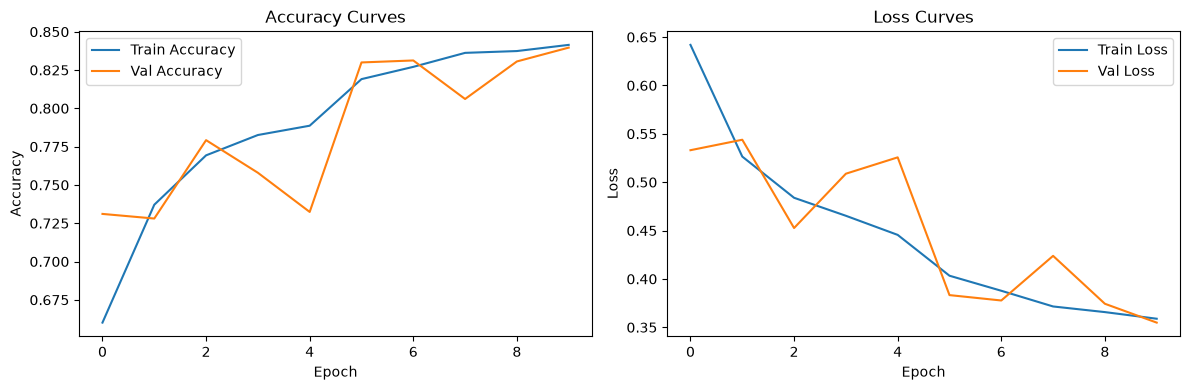

In [25]:
# 6. Plot Training Metrics
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy Curves')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

In [42]:
# 7. Helper Function to Predict ANY New Image (File or URL)


def predict_new_image(trained_model, image_source, target_size=(128, 128)):
    """
    Accepts a local file path (e.g., 'dog.jpg') OR a public web image URL,
    preprocesses it, runs model inference, and plots the result.
    """

    try:
        # Load from Web URL or Local Disk
        if image_source.startswith("http://") or image_source.startswith("https://"):
            response = requests.get(image_source)
            raw_img = Image.open(BytesIO(response.content)).convert('RGB')
        else:
            raw_img = Image.open(image_source).convert('RGB')

    except Exception as e:
        print(f"Error loading image from '{image_source}': {e}")
        return


    # Preprocess Image
    img_resized = raw_img.resize(target_size)

    img_array = np.array(img_resized, dtype=np.float32) / 255.0

    # Add batch dimension -> (1,128,128,3)
    input_batch = np.expand_dims(img_array, axis=0)


    # Model Prediction
    prediction = trained_model.predict(input_batch)


    # For Binary Classification
    probability = prediction[0][0]


    if probability > 0.5:
        label = "Dog"
        confidence = probability * 100
    else:
        label = "Cat"
        confidence = (1 - probability) * 100


    # Display Image
    plt.figure(figsize=(5,5))
    plt.imshow(raw_img)
    plt.axis("off")
    plt.title(f"Prediction: {label}\nConfidence: {confidence:.2f}%")
    plt.show()


    return label, confidence

In [48]:
print(os.getcwd())

/Users/yohanshah/Documents/what


In [49]:
print(os.getcwd())
print(os.listdir())

/Users/yohanshah/Documents/what
['best_cats_vs_dogs_model.keras', '.venv', 'BuildingaCNNforClassvsDogClassification.ipynb']


In [44]:
predict_new_image(
    best_model,
    "/Users/yourname/Desktop/my_local_dog.jpg"
)

Error loading image from '/Users/yourname/Desktop/my_local_dog.jpg': [Errno 2] No such file or directory: '/Users/yourname/Desktop/my_local_dog.jpg'


In [45]:
def predict_new_image(trained_model, image_source, target_size=(128,128)):

    try:
        if image_source.startswith("http"):
            response = requests.get(image_source)
            raw_img = Image.open(
                BytesIO(response.content)
            ).convert("RGB")
        else:
            raw_img = Image.open(image_source).convert("RGB")

    except Exception as e:
        print("Error loading image:", e)
        return


    img_resized = raw_img.resize(target_size)

    img_array = np.array(img_resized, dtype=np.float32)/255.0

    input_batch = np.expand_dims(img_array, axis=0)


    prediction_score = trained_model.predict(
        input_batch,
        verbose=0
    )[0][0]


    if prediction_score > 0.5:
        predicted_label = "Dog"
        confidence = prediction_score * 100
    else:
        predicted_label = "Cat"
        confidence = (1-prediction_score)*100


    plt.imshow(raw_img)
    plt.axis("off")
    plt.title(
        f"{predicted_label} : {confidence:.2f}%"
    )
    plt.show()


    return predicted_label, confidence

In [50]:
predict_new_image(best_model, "cat.jpg")


Error loading image: [Errno 2] No such file or directory: 'cat.jpg'
